# Anomaly Detection with Isolation Forest


In [1]:
# ── 1. IMPORT LIBRARY ──────────────────────────────────────────────────────────
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


# ── ANSI Colors ────────────────────────────────────────────────────────────────
class C:
    RESET = "\033[0m"
    BOLD = "\033[1m"
    RED = "\033[91m"
    GREEN = "\033[92m"
    YELLOW = "\033[93m"
    BLUE = "\033[94m"
    CYAN = "\033[96m"
    WHITE = "\033[97m"
    PURPLE = "\033[95m"


def cprint(msg, color=C.WHITE, bold=False):
    prefix = C.BOLD if bold else ""
    print(f"{prefix}{color}{msg}{C.RESET}")


def section(title):
    bar = "═" * 60
    print(f"\n{C.BOLD}{C.CYAN}{bar}{C.RESET}")
    print(f"{C.BOLD}{C.CYAN}  {title}{C.RESET}")
    print(f"{C.BOLD}{C.CYAN}{bar}{C.RESET}")


# ── Output Folders ─────────────────────────────────────────────────────────────
DIR_IMAGES = Path("output/images")
DIR_MODEL = Path("output/model")
DIR_REPORTS = Path("output/reports")

for d in [DIR_IMAGES, DIR_MODEL, DIR_REPORTS]:
    d.mkdir(parents=True, exist_ok=True)

section("1. IMPORT LIBRARY")
cprint("✔  Semua library berhasil di-import.", C.GREEN, bold=True)
cprint(f"   pandas {pd.__version__} | numpy {np.__version__} | sklearn", C.WHITE)
cprint(f"   Output folders: output/images, output/model, output/reports", C.WHITE)


════════════════════════════════════════════════════════════
  1. IMPORT LIBRARY
════════════════════════════════════════════════════════════
✔  Semua library berhasil di-import.
   pandas 2.3.3 | numpy 2.2.6 | sklearn
   Output folders: output/images, output/model, output/reports


In [2]:
# ── 2. LOAD DATASET ────────────────────────────────────────────────────────────
section("2. LOAD DATASET")

CSV_PATH = Path("creditcard.csv")  # ← Ganti sesuai path dataset Anda

try:
    df_raw = pd.read_csv(CSV_PATH)
    cprint(f"✔  Dataset berhasil dimuat: {CSV_PATH}", C.GREEN, bold=True)
except FileNotFoundError:
    cprint(f"⚠  File tidak ditemukan: {CSV_PATH}", C.YELLOW, bold=True)
    cprint("   Membuat dataset dummy untuk demonstrasi...", C.YELLOW)
    rng = np.random.default_rng(42)
    n_normal = 950
    n_anomaly = 50
    normal = rng.normal(loc=0.0, scale=1.0, size=(n_normal, 5))
    anomalies = rng.uniform(low=-8, high=8, size=(n_anomaly, 5))
    data = np.vstack([normal, anomalies])
    cols = [f"feature_{i+1}" for i in range(5)]
    df_raw = pd.DataFrame(data, columns=cols)
    df_raw.to_csv(CSV_PATH, index=False)
    cprint(f"✔  Dataset dummy dibuat dan disimpan ke: {CSV_PATH}", C.GREEN)

print()
cprint(f"  Jumlah Baris   : {df_raw.shape[0]:,}", C.WHITE)
cprint(f"  Jumlah Kolom   : {df_raw.shape[1]}", C.WHITE)
cprint(f"  Nama Kolom     : {list(df_raw.columns)}", C.WHITE)

print()
cprint("  Tipe Data per Kolom:", C.YELLOW, bold=True)
print(df_raw.dtypes.to_string())

print()
cprint("  5 Data Pertama:", C.YELLOW, bold=True)
display(df_raw.head())

print()
cprint("  Ringkasan Informasi Dataset:", C.YELLOW, bold=True)
df_raw.info()


════════════════════════════════════════════════════════════
  2. LOAD DATASET
════════════════════════════════════════════════════════════
✔  Dataset berhasil dimuat: creditcard.csv

  Jumlah Baris   : 284,807
  Jumlah Kolom   : 31
  Nama Kolom     : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

  Tipe Data per Kolom:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



  Ringkasan Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 n

In [3]:
# ── 3. DATA QUALITY CHECK ──────────────────────────────────────────────────────
section("3. DATA QUALITY CHECK")

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
duplicates = df_raw.duplicated().sum()

cprint("  Missing Values:", C.YELLOW, bold=True)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing (%)": missing_pct})
display(
    missing_df[missing_df["Missing Count"] > 0] if missing.sum() > 0 else missing_df
)

print()
cprint(f"  Duplicate Rows : {C.RED}{duplicates}{C.RESET}", C.WHITE)

print()
cprint("  Statistik Deskriptif:", C.YELLOW, bold=True)
display(df_raw.describe().T.round(4))

if missing.sum() == 0:
    cprint("\n✔  Tidak ada missing value.", C.GREEN, bold=True)
else:
    cprint(
        f"\n⚠  Terdapat {missing.sum()} missing value yang akan ditangani.",
        C.YELLOW,
        bold=True,
    )

if duplicates == 0:
    cprint("✔  Tidak ada duplicate data.", C.GREEN, bold=True)
else:
    cprint(
        f"⚠  Terdapat {duplicates} baris duplikat yang akan dihapus.",
        C.YELLOW,
        bold=True,
    )


════════════════════════════════════════════════════════════
  3. DATA QUALITY CHECK
════════════════════════════════════════════════════════════
  Missing Values:


,Missing Count,Missing (%)
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0



  Duplicate Rows : 1081

  Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950



✔  Tidak ada missing value.
⚠  Terdapat 1081 baris duplikat yang akan dihapus.


In [4]:
# ── 4. DATA CLEANING ───────────────────────────────────────────────────────────
section("4. DATA CLEANING")

df = df_raw.copy()
n_before = len(df)

# Hapus duplikat
df.drop_duplicates(inplace=True)
n_after_dup = len(df)

# Ambil hanya fitur numerik — eksklusikan kolom label dan kolom non-fitur
EXCLUDE_COLS = ["Class", "Time"]
num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns if c not in EXCLUDE_COLS
]
df_num = df[num_cols].copy()

cprint(f"  Kolom dikecualikan : {EXCLUDE_COLS}", C.YELLOW)
cprint(f"  Fitur yang dipakai : {num_cols}", C.WHITE)

# Isi missing value dengan median
for col in num_cols:
    if df_num[col].isnull().sum() > 0:
        median_val = df_num[col].median()
        df_num[col].fillna(median_val, inplace=True)
        cprint(f"  [FILL] {col} → missing diisi median ({median_val:.4f})", C.YELLOW)

n_after_clean = len(df_num)

cprint(f"\n  Sebelum Cleaning : {n_before:,} baris", C.WHITE)
cprint(f"  Setelah Cleaning : {n_after_clean:,} baris", C.WHITE)
cprint(f"  Fitur Numerik    : {num_cols}", C.WHITE)
cprint(f"  Jumlah Fitur     : {len(num_cols)}", C.WHITE)

print()
cprint("  5 Baris Pertama Setelah Cleaning:", C.YELLOW, bold=True)
display(df_num.head())

cprint("\n✔  Data cleaning selesai.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  4. DATA CLEANING
════════════════════════════════════════════════════════════
  Kolom dikecualikan : ['Class', 'Time']
  Fitur yang dipakai : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

  Sebelum Cleaning : 284,807 baris
  Setelah Cleaning : 283,726 baris
  Fitur Numerik    : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
  Jumlah Fitur     : 29

  5 Baris Pertama Setelah Cleaning:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99



✔  Data cleaning selesai.



════════════════════════════════════════════════════════════
  5. EXPLORATORY DATA ANALYSIS (EDA)
════════════════════════════════════════════════════════════

  [5.1] Histogram seluruh fitur numerik


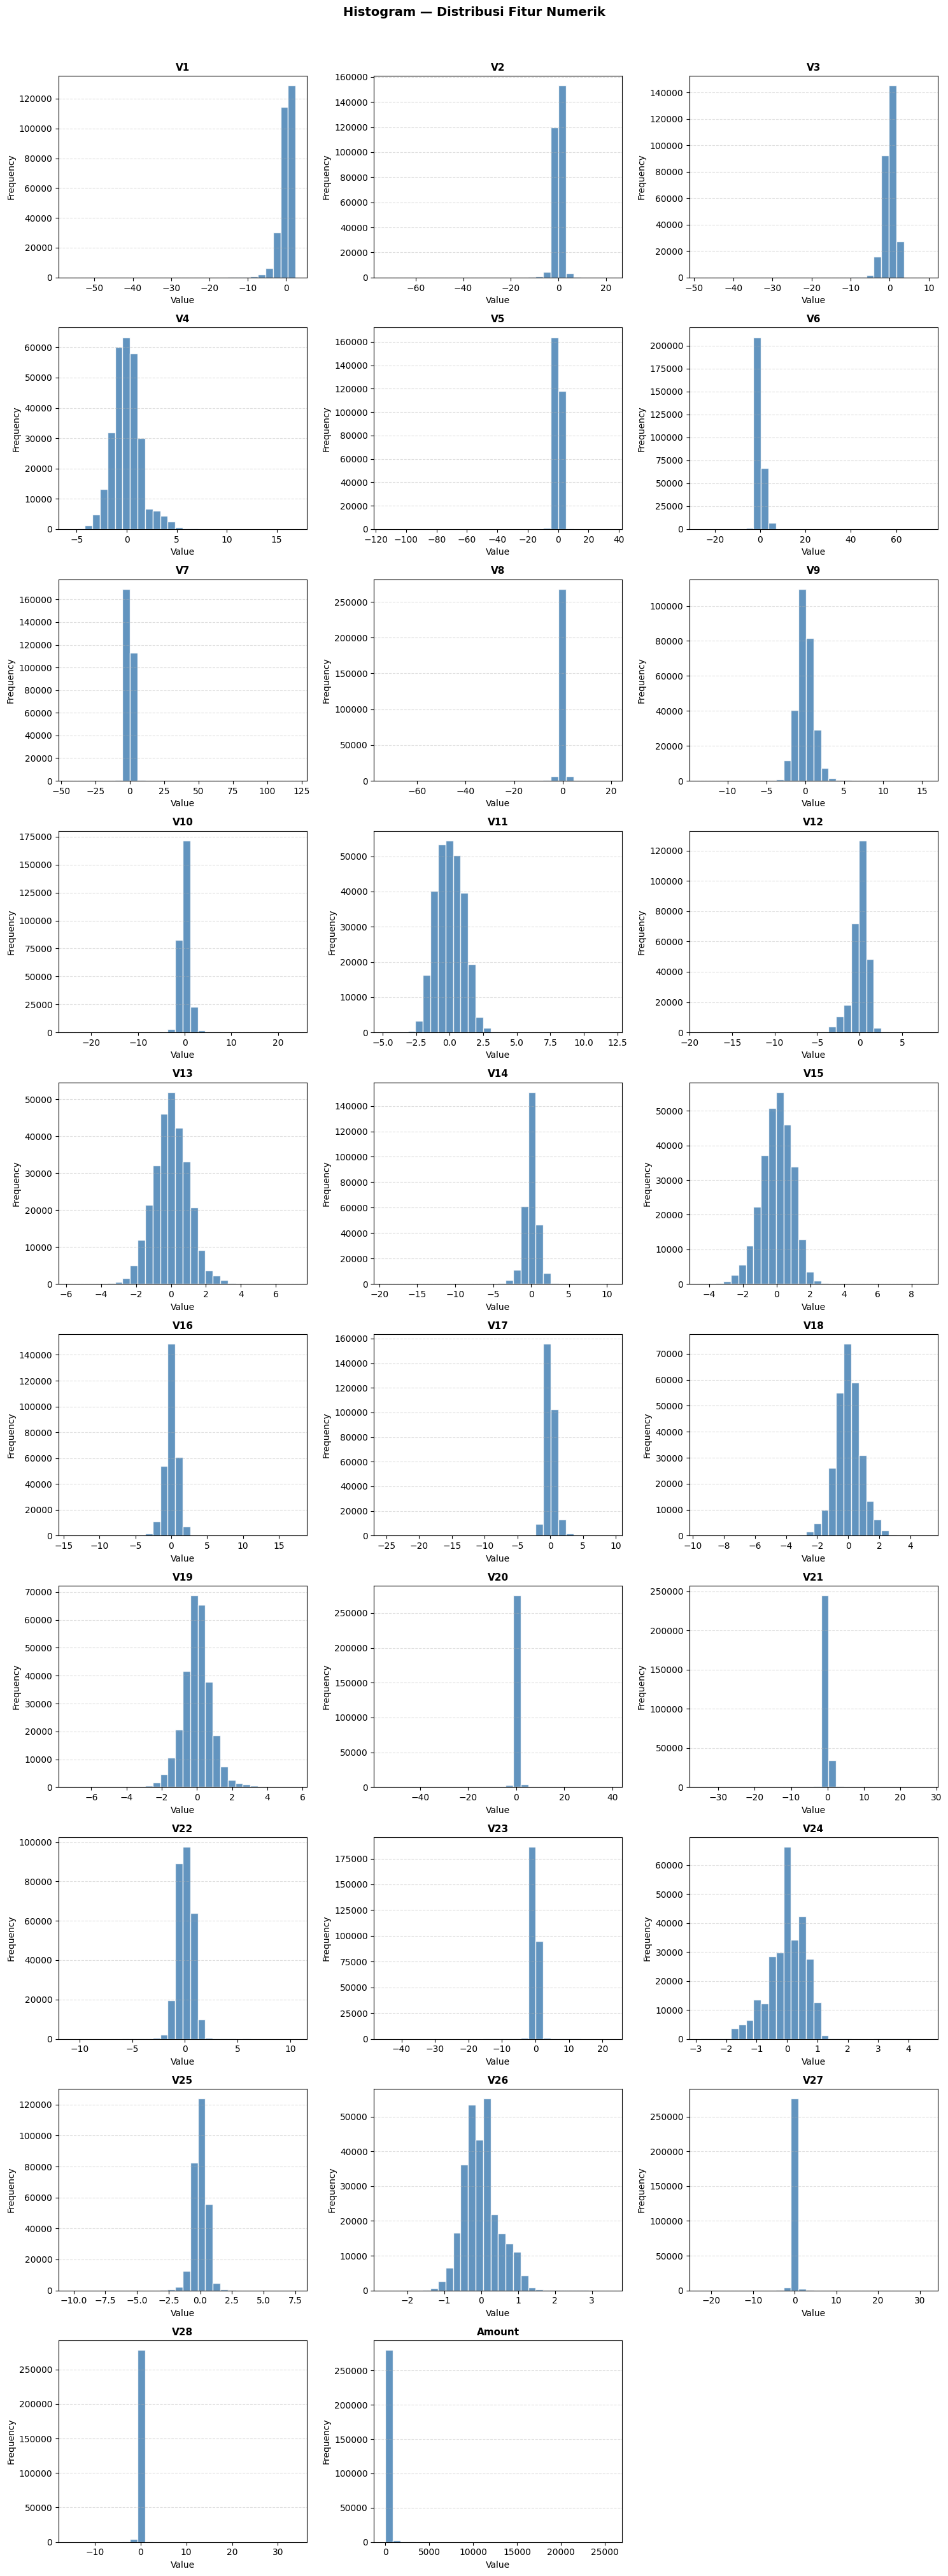

  ✔  Gambar disimpan: output/images/histogram_features.png

  [5.2] Boxplot seluruh fitur numerik


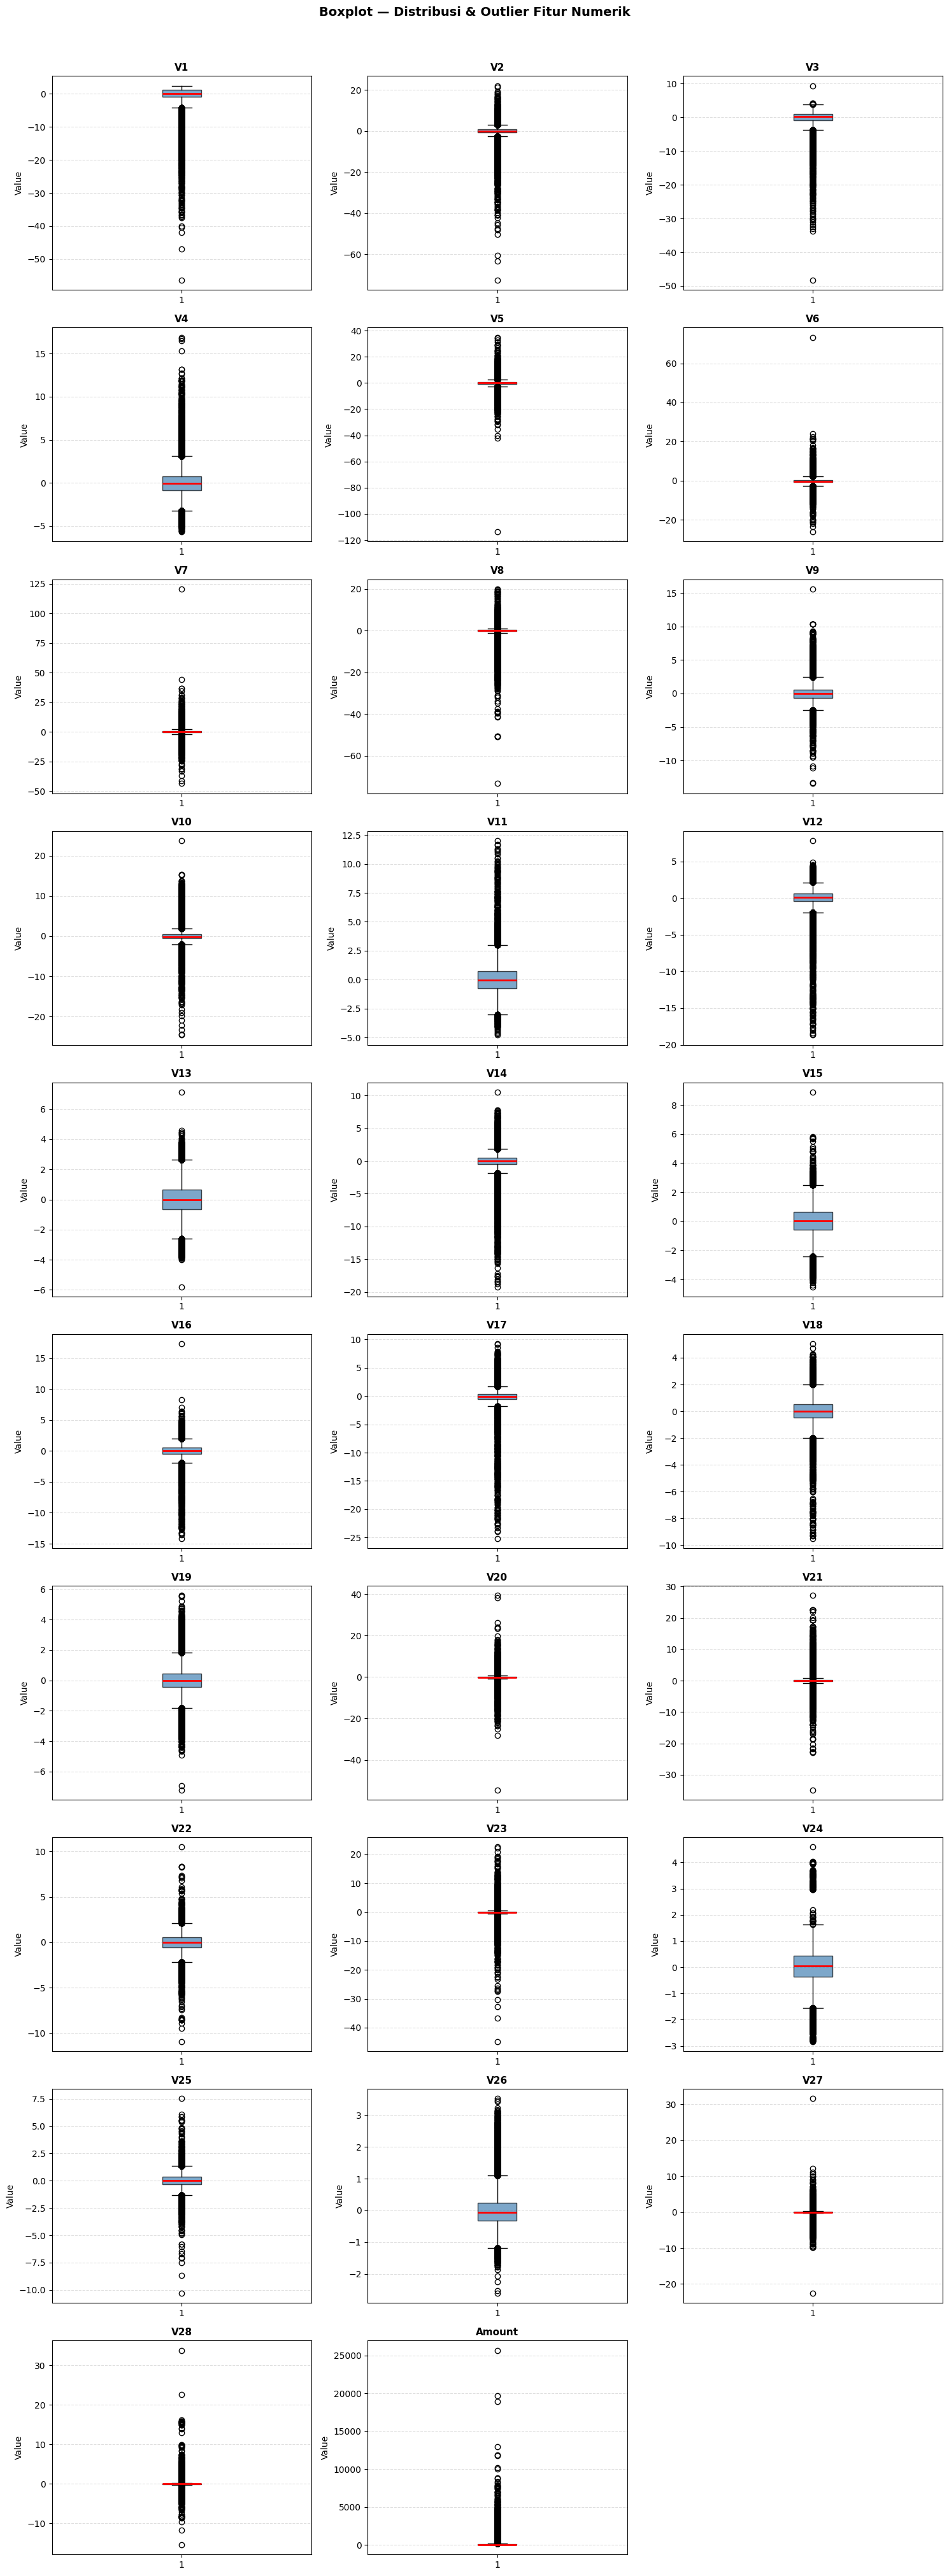

  ✔  Gambar disimpan: output/images/boxplot_features.png

  [5.3] Correlation Heatmap


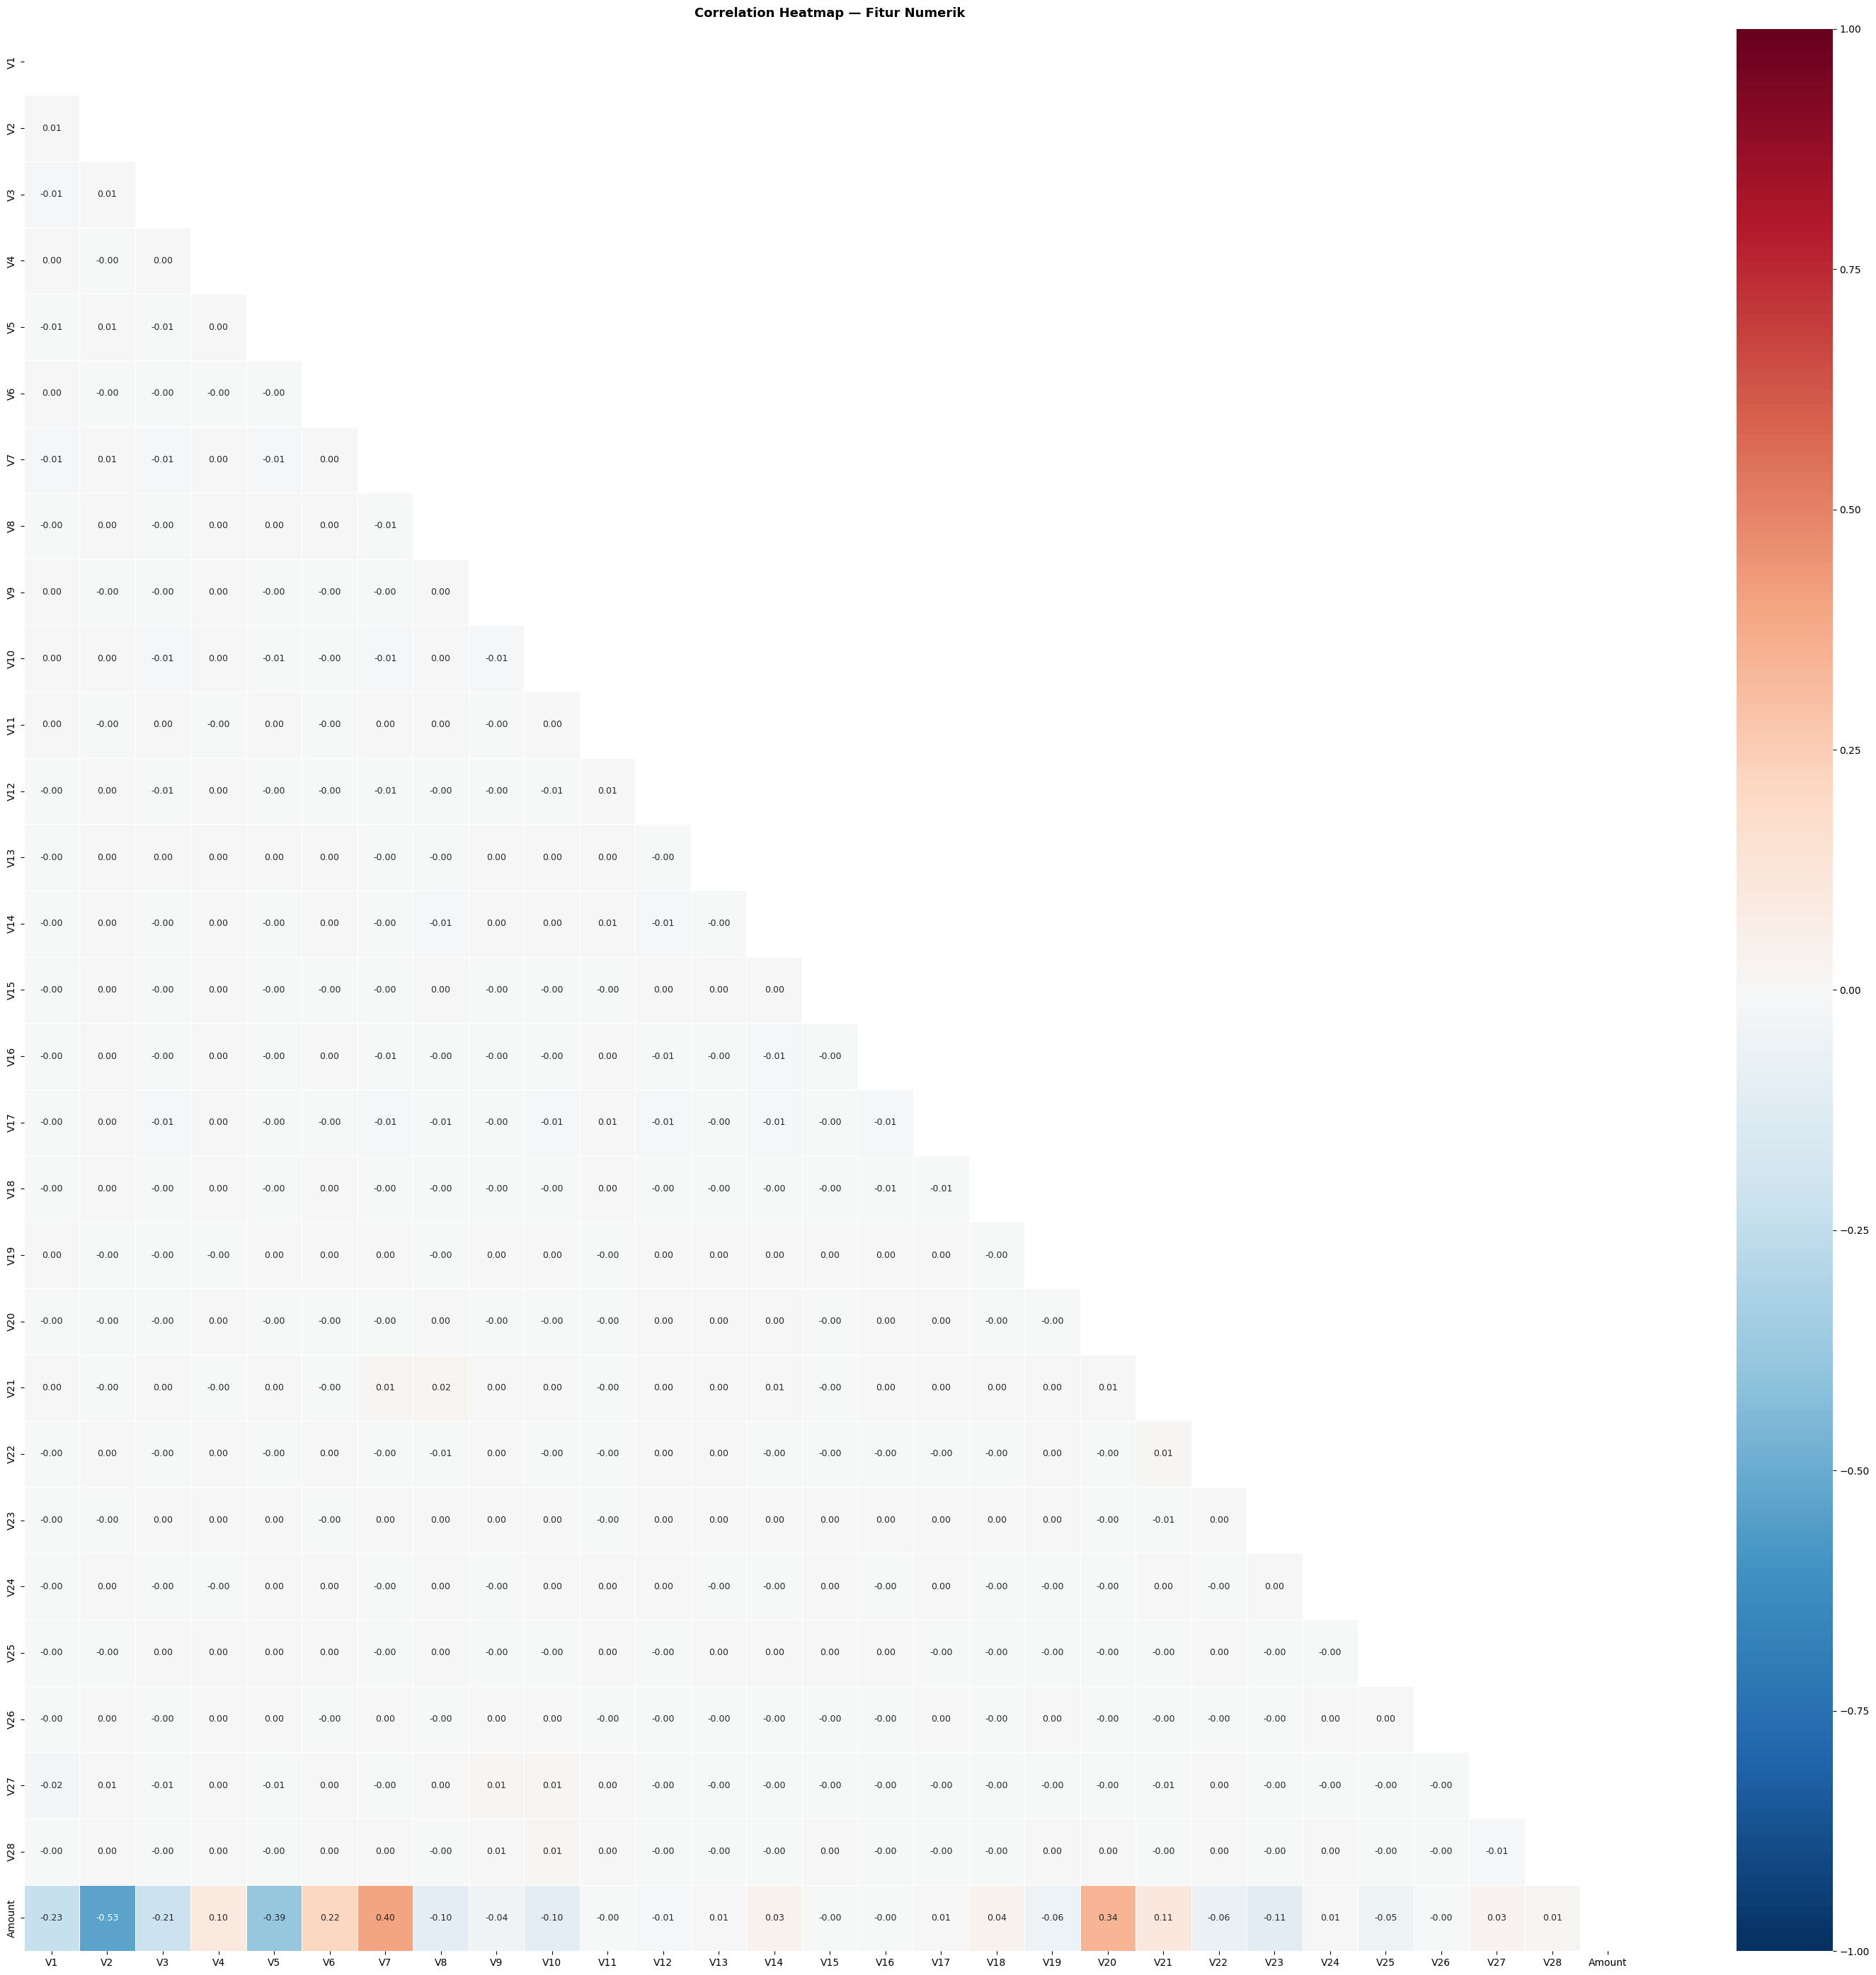

  ✔  Gambar disimpan: output/images/correlation_heatmap.png


In [5]:
# ── 5. EDA ─────────────────────────────────────────────────────────────────────
section("5. EXPLORATORY DATA ANALYSIS (EDA)")

PALETTE = "Blues_r"
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})


def save_fig(fig, name):
    path = DIR_IMAGES / name
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    cprint(f"  ✔  Gambar disimpan: {path}", C.GREEN)


n_cols_plot = len(num_cols)
ncols = 3
nrows = (n_cols_plot + ncols - 1) // ncols

# ── Histogram ─────────────────────────────────────────────────────────────────
cprint("\n  [5.1] Histogram seluruh fitur numerik", C.CYAN, bold=True)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(
        df_num[col].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.85
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(axis="y", linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Histogram — Distribusi Fitur Numerik", fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
save_fig(fig, "histogram_features.png")

# ── Boxplot ────────────────────────────────────────────────────────────────────
cprint("\n  [5.2] Boxplot seluruh fitur numerik", C.CYAN, bold=True)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(
        df_num[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.7),
        medianprops=dict(color="red", linewidth=2),
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Value")
    axes[i].grid(axis="y", linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Boxplot — Distribusi & Outlier Fitur Numerik",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
save_fig(fig, "boxplot_features.png")

# ── Correlation Heatmap ────────────────────────────────────────────────────────
cprint("\n  [5.3] Correlation Heatmap", C.CYAN, bold=True)
corr_mat = df_num.corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(max(8, n_cols_plot), max(6, n_cols_plot - 1)))
sns.heatmap(
    corr_mat,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    ax=ax,
)
ax.set_title(
    "Correlation Heatmap — Fitur Numerik", fontsize=13, fontweight="bold", pad=12
)
plt.tight_layout()
save_fig(fig, "correlation_heatmap.png")

In [6]:
# ── 6. FEATURE SCALING ─────────────────────────────────────────────────────────
section("6. FEATURE SCALING")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)
df_scaled = pd.DataFrame(X_scaled, columns=num_cols)

cprint("  Sebelum Scaling (5 baris pertama):", C.YELLOW, bold=True)
display(df_num.head())

print()
cprint("  Sesudah Scaling (5 baris pertama):", C.YELLOW, bold=True)
display(df_scaled.head())

cprint("\n  Statistik setelah scaling (mean ≈ 0, std ≈ 1):", C.WHITE)
display(df_scaled.describe().T[["mean", "std", "min", "max"]].round(4))

cprint("\n✔  Feature scaling dengan StandardScaler selesai.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  6. FEATURE SCALING
════════════════════════════════════════════════════════════
  Sebelum Scaling (5 baris pertama):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99



  Sesudah Scaling (5 baris pertama):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.701082,-0.041687,1.680101,0.976623,-0.247020,0.348012,0.193700,0.084434,0.333534,0.085688,...,0.326273,-0.024777,0.383483,-0.177444,0.110157,0.247059,-0.392622,0.333033,-0.065850,0.244200
1,0.608792,0.164138,0.109279,0.318998,0.042258,-0.060980,-0.065656,0.072903,-0.231703,-0.153784,...,-0.089963,-0.311372,-0.881454,0.162081,-0.561503,0.321175,0.260854,-0.027154,0.043219,-0.342584
2,-0.700336,-0.811337,1.174270,0.270648,-0.366756,1.352655,0.643223,0.210788,-1.381169,0.194242,...,0.681564,0.343094,1.065068,1.457772,-1.138484,-0.628161,-0.288861,-0.144325,-0.183824,1.158900
3,-0.499064,-0.109972,1.187383,-0.608355,-0.008814,0.937245,0.192079,0.320843,-1.264664,-0.049713,...,-0.270428,-0.149093,0.007299,-0.305465,-1.941446,1.242487,-0.460694,0.154039,0.185687,0.139886
4,-0.597606,0.535539,1.025470,0.287092,-0.297036,0.072873,0.481517,-0.228725,0.747917,0.700958,...,0.530343,-0.012516,1.101780,-0.220709,0.232904,-0.394800,1.041677,0.550001,0.654234,-0.073813



  Statistik setelah scaling (mean ≈ 0, std ≈ 1):


,mean,std,min,max
V1,-0.0,1.0,-28.9593,1.2572
V2,-0.0,1.0,-44.1559,13.3976
V3,-0.0,1.0,-32.0328,6.2180
V4,0.0,1.0,-4.0166,11.9350
V5,0.0,1.0,-82.6032,25.2721
V6,0.0,1.0,-19.6402,55.0351
V7,-0.0,1.0,-35.4813,98.2255
V8,-0.0,1.0,-62.0972,16.9696
V9,-0.0,1.0,-12.2616,14.2371
V10,0.0,1.0,-22.8416,22.0610



✔  Feature scaling dengan StandardScaler selesai.


In [7]:
# ── 7. TRAINING ISOLATION FOREST ───────────────────────────────────────────────
section("7. TRAINING ISOLATION FOREST")

cprint("  Melatih model Isolation Forest...", C.WHITE)

# Hitung contamination dari ground truth
if "Class" in df.columns:
    # = 473 fraud / 283.726 total = 0.001667
    contamination_rate = df["Class"].sum() / len(df)
    cprint(
        f'  Contamination dari data : {contamination_rate:.6f} ({df["Class"].sum()} fraud dari {len(df):,})',
        C.CYAN,
    )
else:
    contamination_rate = 0.01  # fallback default 1%
    cprint(f"  Contamination (default) : {contamination_rate}", C.YELLOW)

iso_forest = IsolationForest(
    n_estimators=200, contamination=contamination_rate, random_state=42
)
iso_forest.fit(X_scaled)
y_pred = iso_forest.predict(X_scaled)  # 1 = normal, -1 = anomaly

n_total = len(y_pred)
n_anomaly = (y_pred == -1).sum()
n_normal = (y_pred == 1).sum()

print()
cprint(f"  Jumlah Data   : {C.WHITE}{n_total:,}{C.RESET}", C.CYAN)
cprint(f"  Normal        : {C.GREEN}{n_normal:,}{C.RESET}", C.CYAN)
cprint(f"  Anomali       : {C.RED}{n_anomaly:,}{C.RESET}", C.CYAN)
cprint(f"  Contamination : {contamination_rate:.6f}", C.CYAN)

cprint("\n✔  Training Isolation Forest selesai.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  7. TRAINING ISOLATION FOREST
════════════════════════════════════════════════════════════
  Melatih model Isolation Forest...
  Contamination dari data : 0.001667 (473 fraud dari 283,726)

  Jumlah Data   : 283,726
  Normal        : 283,253
  Anomali       : 473
  Contamination : 0.001667

✔  Training Isolation Forest selesai.


In [8]:
# ── 8. ANOMALY SCORE ───────────────────────────────────────────────────────────
section("8. ANOMALY SCORE")

# decision_function: skor lebih rendah = lebih anomali
scores = iso_forest.decision_function(X_scaled)

df_result = df_num.copy()
df_result["anomaly_score"] = scores

cprint(
    f"  Skor Tertinggi (paling normal) : {C.GREEN}{scores.max():.6f}{C.RESET}", C.WHITE
)
cprint(
    f"  Skor Terendah  (paling anomali): {C.RED}{scores.min():.6f}{C.RESET}", C.WHITE
)
cprint(
    f"  Rata-rata Skor                 : {C.CYAN}{scores.mean():.6f}{C.RESET}", C.WHITE
)
cprint(
    f"  Std Dev Skor                   : {C.CYAN}{scores.std():.6f}{C.RESET}", C.WHITE
)

print()
cprint("  Distribusi Anomaly Score (5 statistik):", C.YELLOW, bold=True)
display(pd.Series(scores, name="anomaly_score").describe().to_frame().T.round(6))

cprint("\n✔  Anomaly score berhasil dihitung.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  8. ANOMALY SCORE
════════════════════════════════════════════════════════════
  Skor Tertinggi (paling normal) : 0.311111
  Skor Terendah  (paling anomali): -0.112985
  Rata-rata Skor                 : 0.252235
  Std Dev Skor                   : 0.043589

  Distribusi Anomaly Score (5 statistik):


,count,mean,std,min,25%,50%,75%,max
anomaly_score,283726.0,0.252235,0.043589,-0.112985,0.236315,0.262223,0.281531,0.311111



✔  Anomaly score berhasil dihitung.


In [9]:
# ── 9. HASIL DETEKSI ANOMALI ───────────────────────────────────────────────────
section("9. HASIL DETEKSI ANOMALI")

df_result["anomaly"] = y_pred  # 1 = Normal, -1 = Anomaly
df_result["label"] = df_result["anomaly"].map({1: "Normal", -1: "Anomaly"})

total_normal = (df_result["anomaly"] == 1).sum()
total_anomaly = (df_result["anomaly"] == -1).sum()
pct_anomaly = total_anomaly / len(df_result) * 100

print()
cprint(f"  ┌─────────────────────────────────────────┐", C.CYAN)
cprint(f"  │  Total Data         : {len(df_result):>8,}           │", C.CYAN)
cprint(
    f"  │  Normal             : {C.GREEN}{total_normal:>8,}{C.CYAN}           │", C.CYAN
)
cprint(
    f"  │  Anomaly            : {C.RED}{total_anomaly:>8,}{C.CYAN}           │", C.CYAN
)
cprint(
    f"  │  Persentase Anomaly : {C.RED}{pct_anomaly:>8.2f}%{C.CYAN}          │", C.CYAN
)
cprint(f"  └─────────────────────────────────────────┘", C.CYAN)

print()
cprint("  Distribusi Label:", C.YELLOW, bold=True)
display(df_result["label"].value_counts().to_frame())

cprint("\n✔  Deteksi anomali selesai.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  9. HASIL DETEKSI ANOMALI
════════════════════════════════════════════════════════════

  ┌─────────────────────────────────────────┐
  │  Total Data         :  283,726           │
  │  Normal             :  283,253           │
  │  Anomaly            :      473           │
  │  Persentase Anomaly :     0.17%          │
  └─────────────────────────────────────────┘

  Distribusi Label:


,count
label,
Normal,283253
Anomaly,473



✔  Deteksi anomali selesai.



════════════════════════════════════════════════════════════
  9b. EVALUASI MODEL TERHADAP GROUND TRUTH (Class)
════════════════════════════════════════════════════════════
  Confusion Matrix:


,Predicted Normal (0),Predicted Fraud (1)
Actual Normal (0),282887,366
Actual Fraud (1),366,107



  True Negative  (TN) : 282,887
  False Positive (FP) : 366
  False Negative (FN) : 366
  True Positive  (TP) : 107

  Metrik Evaluasi:


,Metrik,Nilai
0,Accuracy,0.9974
1,Precision,0.2262
2,Recall,0.2262
3,F1-Score,0.2262
4,ROC-AUC,0.9484
5,AUCPR,0.1243



  Catatan: ROC-AUC = 0.9484, AUCPR = 0.1243.
  Pada dataset yang sangat imbalanced, AUCPR lebih merepresentasikan
  kemampuan model menangkap kelas minoritas (fraud) dibanding ROC-AUC.


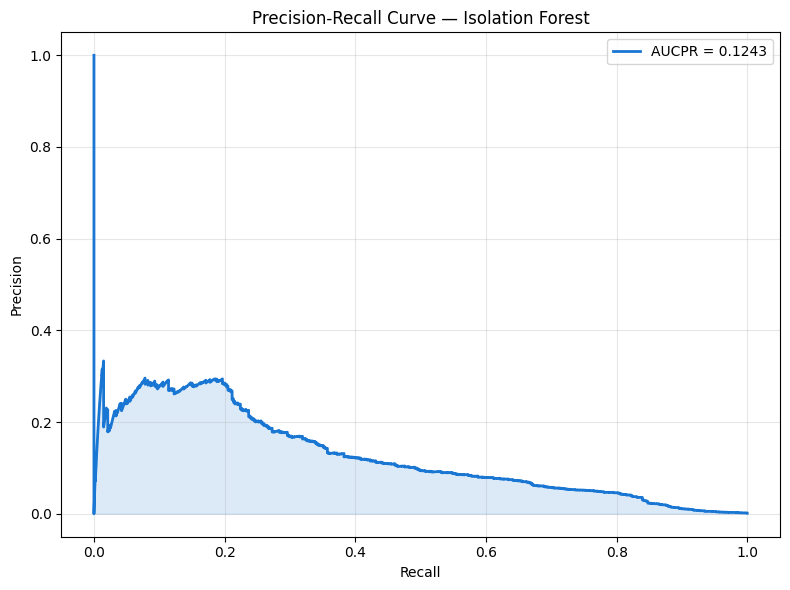


✔  Evaluasi model selesai. Kurva disimpan ke: output/images/precision_recall_curve.png


In [10]:
# ── 9b. EVALUASI: CONFUSION MATRIX & METRIK KLASIFIKASI ─────────────────────────
section("9b. EVALUASI MODEL TERHADAP GROUND TRUTH (Class)")

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

# Ground truth: Class asli (1 = fraud, 0 = normal), index sejajar dengan df_num/y_pred
y_true = df["Class"].values

# Samakan polaritas label: model -> 1 = normal, -1 = anomaly
# Ground truth -> 1 = fraud, 0 = normal
# Konversi prediksi model ke skema yang sama: 1 = fraud (anomaly), 0 = normal
y_pred_bin = np.where(y_pred == -1, 1, 0)

# Skor anomali dibalik agar "semakin tinggi = semakin mirip fraud"
# (decision_function: skor rendah = anomali, jadi dibalik tandanya)
y_score = -scores

cm = confusion_matrix(y_true, y_pred_bin)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true, y_pred_bin)
prec = precision_score(y_true, y_pred_bin, zero_division=0)
rec = recall_score(y_true, y_pred_bin, zero_division=0)
f1 = f1_score(y_true, y_pred_bin, zero_division=0)
roc_auc = roc_auc_score(y_true, y_score)
aucpr = average_precision_score(y_true, y_score)

cprint("  Confusion Matrix:", C.YELLOW, bold=True)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal (0)", "Actual Fraud (1)"],
    columns=["Predicted Normal (0)", "Predicted Fraud (1)"],
)
display(cm_df)

print()
cprint(f"  True Negative  (TN) : {tn:,}", C.WHITE)
cprint(f"  False Positive (FP) : {fp:,}", C.WHITE)
cprint(f"  False Negative (FN) : {fn:,}", C.WHITE)
cprint(f"  True Positive  (TP) : {tp:,}", C.WHITE)

print()
cprint("  Metrik Evaluasi:", C.YELLOW, bold=True)
metrics_df = pd.DataFrame(
    {
        "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "AUCPR"],
        "Nilai": [acc, prec, rec, f1, roc_auc, aucpr],
    }
)
display(metrics_df.style.format({"Nilai": "{:.4f}"}))

cprint(
    f"\n  Catatan: ROC-AUC = {roc_auc:.4f}, AUCPR = {aucpr:.4f}.", C.CYAN
)
cprint(
    "  Pada dataset yang sangat imbalanced, AUCPR lebih merepresentasikan",
    C.CYAN,
)
cprint(
    "  kemampuan model menangkap kelas minoritas (fraud) dibanding ROC-AUC.",
    C.CYAN,
)

# ── Plot Precision-Recall Curve ─────────────────────────────────────────────
precisions, recalls, _ = precision_recall_curve(y_true, y_score)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recalls, precisions, color="#1976D2", linewidth=2, label=f"AUCPR = {aucpr:.4f}")
ax.fill_between(recalls, precisions, alpha=0.15, color="#1976D2")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Isolation Forest")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
pr_curve_path = DIR_IMAGES / "precision_recall_curve.png"
plt.savefig(pr_curve_path, dpi=150)
plt.show()

cprint(f"\n✔  Evaluasi model selesai. Kurva disimpan ke: {pr_curve_path}", C.GREEN, bold=True)



════════════════════════════════════════════════════════════
  10. VISUALISASI HASIL
════════════════════════════════════════════════════════════
  [10.1] Scatter Plot PCA 2D


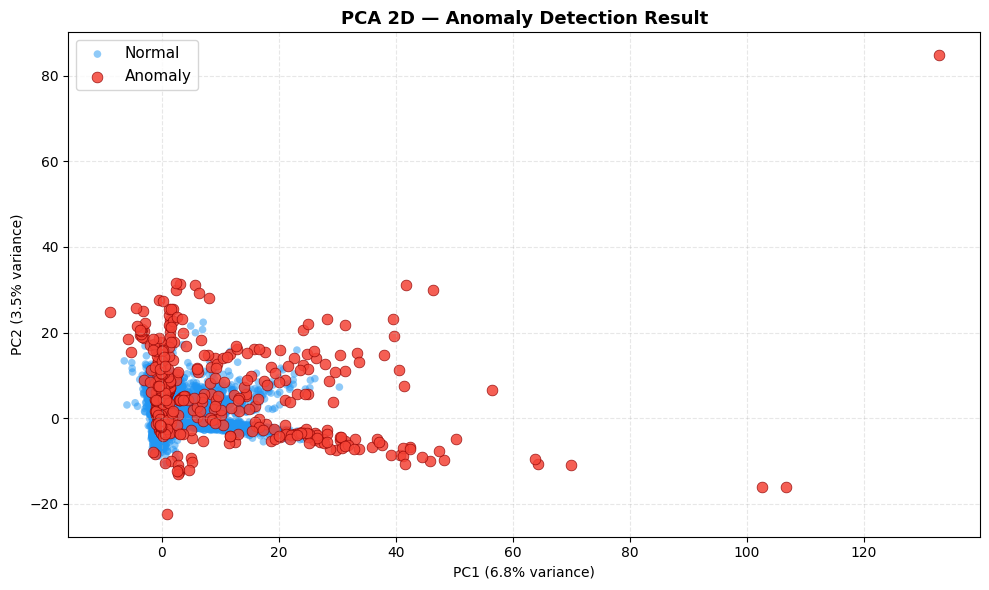

  ✔  Gambar disimpan: output/images/pca_2d_anomaly.png
  [10.2] Scatter Plot PCA 3D


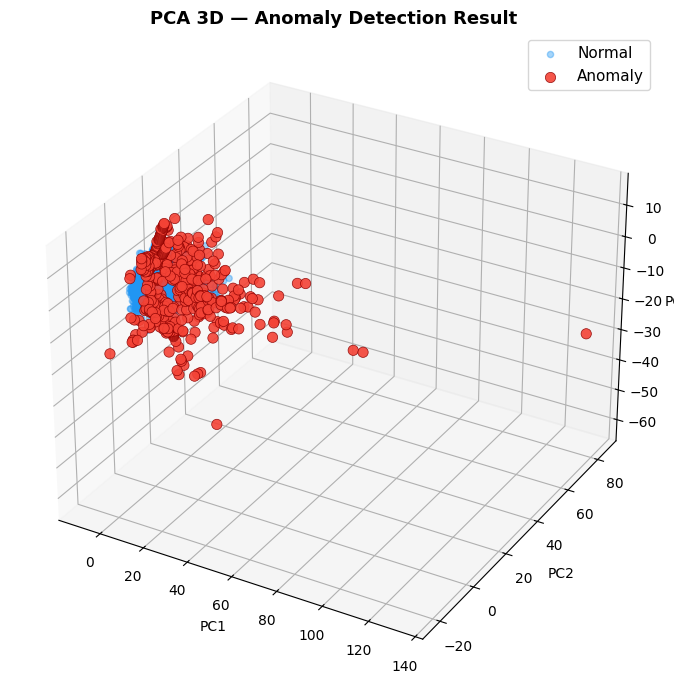

  ✔  Gambar disimpan: output/images/pca_3d_anomaly.png
  [10.3] Anomaly Distribution


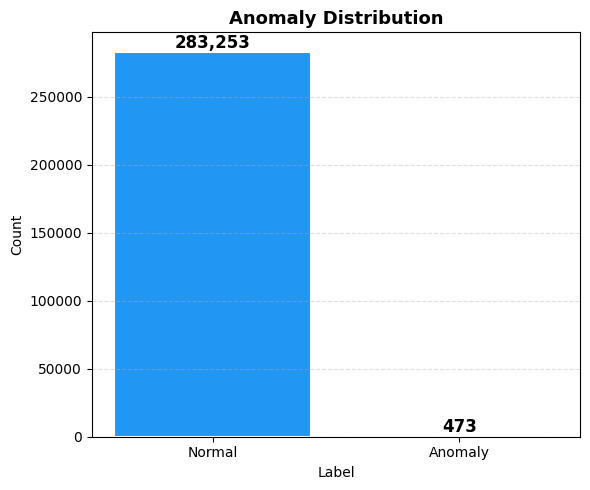

  ✔  Gambar disimpan: output/images/anomaly_distribution.png
  [10.4] Anomaly Score Distribution


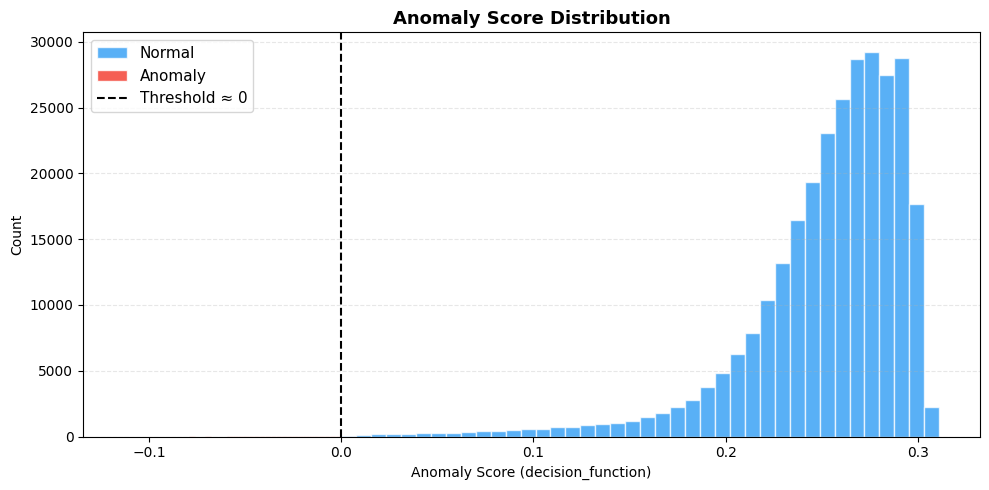

  ✔  Gambar disimpan: output/images/anomaly_score_distribution.png

✔  Semua visualisasi selesai.


In [11]:
# ── 10. VISUALISASI HASIL ──────────────────────────────────────────────────────
section("10. VISUALISASI HASIL")

COLOR_NORMAL = "#2196F3"  # Biru
COLOR_ANOMALY = "#F44336"  # Merah

colors = np.where(df_result["anomaly"] == 1, COLOR_NORMAL, COLOR_ANOMALY)

# ── PCA 2D ────────────────────────────────────────────────────────────────────
cprint("  [10.1] Scatter Plot PCA 2D", C.CYAN, bold=True)
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    X_2d[df_result["anomaly"] == 1, 0],
    X_2d[df_result["anomaly"] == 1, 1],
    c=COLOR_NORMAL,
    alpha=0.5,
    s=30,
    label="Normal",
    edgecolors="none",
)
ax.scatter(
    X_2d[df_result["anomaly"] == -1, 0],
    X_2d[df_result["anomaly"] == -1, 1],
    c=COLOR_ANOMALY,
    alpha=0.85,
    s=60,
    label="Anomaly",
    edgecolors="darkred",
    linewidths=0.5,
)
ax.set_title("PCA 2D — Anomaly Detection Result", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(fontsize=11)
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
save_fig(fig, "pca_2d_anomaly.png")

# ── PCA 3D ────────────────────────────────────────────────────────────────────
cprint("  [10.2] Scatter Plot PCA 3D", C.CYAN, bold=True)
pca3 = PCA(n_components=min(3, len(num_cols)), random_state=42)
X_3d = pca3.fit_transform(X_scaled)

if X_3d.shape[1] >= 3:
    fig = plt.figure(figsize=(11, 7))
    ax3 = fig.add_subplot(111, projection="3d")
    mask_n = df_result["anomaly"] == 1
    mask_a = df_result["anomaly"] == -1
    ax3.scatter(
        X_3d[mask_n, 0],
        X_3d[mask_n, 1],
        X_3d[mask_n, 2],
        c=COLOR_NORMAL,
        alpha=0.4,
        s=20,
        label="Normal",
    )
    ax3.scatter(
        X_3d[mask_a, 0],
        X_3d[mask_a, 1],
        X_3d[mask_a, 2],
        c=COLOR_ANOMALY,
        alpha=0.9,
        s=55,
        label="Anomaly",
        edgecolors="darkred",
        linewidths=0.5,
    )
    ax3.set_title("PCA 3D — Anomaly Detection Result", fontsize=13, fontweight="bold")
    ax3.set_xlabel("PC1")
    ax3.set_ylabel("PC2")
    ax3.set_zlabel("PC3")
    ax3.legend(fontsize=11)
    plt.tight_layout()
    save_fig(fig, "pca_3d_anomaly.png")
else:
    cprint("  ⚠  Fitur < 3, PCA 3D dilewati.", C.YELLOW)

# ── Anomaly Distribution ──────────────────────────────────────────────────────
cprint("  [10.3] Anomaly Distribution", C.CYAN, bold=True)
counts = df_result["label"].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    counts.index,
    counts.values,
    color=[COLOR_NORMAL, COLOR_ANOMALY][: len(counts)],
    edgecolor="white",
    linewidth=1.5,
)
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )
ax.set_title("Anomaly Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
save_fig(fig, "anomaly_distribution.png")

# ── Anomaly Score Distribution ─────────────────────────────────────────────────
cprint("  [10.4] Anomaly Score Distribution", C.CYAN, bold=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    df_result.loc[df_result["anomaly"] == 1, "anomaly_score"],
    bins=40,
    alpha=0.75,
    color=COLOR_NORMAL,
    label="Normal",
    edgecolor="white",
)
ax.hist(
    df_result.loc[df_result["anomaly"] == -1, "anomaly_score"],
    bins=40,
    alpha=0.85,
    color=COLOR_ANOMALY,
    label="Anomaly",
    edgecolor="white",
)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Threshold ≈ 0")
ax.set_title("Anomaly Score Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Anomaly Score (decision_function)")
ax.set_ylabel("Count")
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
save_fig(fig, "anomaly_score_distribution.png")

cprint("\n✔  Semua visualisasi selesai.", C.GREEN, bold=True)

In [12]:
# ── 11. TOP ANOMALY ────────────────────────────────────────────────────────────
section("11. TOP 20 ANOMALI TERPARAH")

top_anomaly = (
    df_result[df_result["anomaly"] == -1]
    .sort_values("anomaly_score", ascending=True)
    .head(20)
)

cprint(
    f"  Menampilkan {len(top_anomaly)} data dengan anomaly_score terendah:",
    C.YELLOW,
    bold=True,
)
display(
    top_anomaly.drop(columns=["label"])
    .style.background_gradient(subset=["anomaly_score"], cmap="Reds_r")
    .format({"anomaly_score": "{:.6f}"})
)

cprint(f"\n✔  Top anomali ditampilkan.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  11. TOP 20 ANOMALI TERPARAH
════════════════════════════════════════════════════════════
  Menampilkan 20 data dengan anomaly_score terendah:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,anomaly_score,anomaly
274771,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,-12.005487,6.853897,-9.189418,7.126883,-6.795942,8.877742,17.315112,-7.173805,-1.968044,5.501747,-54.497720,-21.620120,5.712303,-1.581098,4.584549,4.554683,3.415636,31.612198,-15.430084,25691.160000,-0.112985,-1
173353,-28.262775,-26.551515,-15.930586,6.945207,-19.203497,13.461737,23.718783,-9.419314,5.264773,2.362488,4.021344,-0.229003,2.788180,-3.661824,4.824577,5.196516,-2.571068,-3.977141,0.900340,-21.028272,-8.701341,-2.932575,-22.459170,1.771003,-3.684737,-0.106886,4.071877,-2.383081,4861.640000,-0.111477,-1
151296,-34.549296,-60.464618,-21.340854,16.875344,-19.229075,6.335259,24.422716,-4.964566,0.188912,-8.908182,-0.083514,-2.281866,3.739366,5.989210,2.582162,3.032874,0.530779,4.712398,-6.938297,38.117209,11.502580,-9.499423,-16.513186,0.744341,-7.081325,-2.604551,-3.550963,3.250802,18910.000000,-0.107027,-1
173054,-22.132223,-19.815536,-11.183644,4.829787,-13.128465,10.689779,18.257057,-8.685409,5.250410,3.366931,3.790098,-0.362721,1.940820,-4.047297,4.030891,3.860328,-2.498315,-3.929336,1.249591,-20.522094,-8.214994,-1.969170,-18.416215,1.376122,-2.965101,0.149369,4.077221,-1.975801,4543.640000,-0.104370,-1
220090,-37.558067,-29.335992,-24.962322,8.413616,-35.182120,21.550496,36.877368,-8.915982,5.046566,0.909474,3.919686,-0.384260,4.316156,-3.113694,5.667667,8.289890,-2.490935,-3.570907,1.663899,-28.009635,-11.263235,-1.150828,-7.800902,1.272716,1.965365,0.767817,3.248189,13.013546,5964.950000,-0.101423,-1
176335,-35.274010,-34.889342,-15.070015,9.211564,-6.226835,3.828063,10.778805,-6.462003,6.588395,4.524278,3.556634,1.445127,3.048211,-2.463534,4.970057,4.516603,-1.784110,-3.839299,0.356394,-15.595737,-7.090340,-4.722186,-26.429741,1.765486,-4.564506,-0.594620,1.110848,-0.714247,1676.600000,-0.101329,-1
58465,-36.802320,-63.344698,-20.645794,16.715537,-20.672064,7.694002,24.956587,-4.730111,-2.687312,-8.423404,1.186360,1.879982,3.496723,4.082503,1.406178,0.773133,0.902964,5.041069,-7.213527,39.420904,11.455313,-10.933144,-17.173665,1.180700,-7.025783,-2.534330,-3.602479,3.450224,19656.530000,-0.099166,-1
206228,-37.054295,-35.699829,-19.880878,9.552849,-16.701866,9.741883,21.014587,-6.414390,5.751017,2.598367,3.255050,0.731349,3.650208,-2.362784,4.766775,5.600123,-2.138121,-3.025254,0.307196,-15.406594,-7.167247,-2.817629,-14.414207,1.223594,-3.129609,-0.689271,0.289897,-1.181892,1676.600000,-0.097311,-1
206255,-40.042537,-38.430842,-21.277176,10.527243,-16.296090,8.799515,19.553200,-6.221785,6.121324,2.881454,3.274574,1.283747,3.951391,-1.887121,5.126187,5.998263,-1.888357,-3.277844,0.088993,-15.692536,-7.292757,-3.834799,-20.034848,1.575385,-4.196468,-0.851794,0.375152,-1.178134,1676.600000,-0.096955,-1
231454,-35.905105,-31.041362,-19.472908,9.216960,-18.863553,10.713326,16.687265,-9.609234,3.296559,-1.368484,2.545327,1.882563,3.727829,0.418748,5.501117,7.059132,-0.955952,-2.113101,-0.083183,-21.964898,-2.661701,-3.016337,-19.331255,0.987774,-2.180899,-0.172480,6.228140,-2.830091,3552.960000,-0.096925,-1



✔  Top anomali ditampilkan.



════════════════════════════════════════════════════════════
  12. FEATURE IMPORTANCE APPROXIMATION
════════════════════════════════════════════════════════════
  Menggunakan Korelasi Absolut dengan Anomaly Score...
  Ranking Fitur (Permutation Importance):


,Feature,Importance,Std Dev
1,V1,0.617293,0.000000
2,Amount,0.401406,0.000000
3,V3,0.279663,0.000000
4,V6,0.239361,0.000000
5,V12,0.211954,0.000000
6,V8,0.202942,0.000000
7,V2,0.161254,0.000000
8,V17,0.156400,0.000000
9,V20,0.112036,0.000000
10,V10,0.110587,0.000000


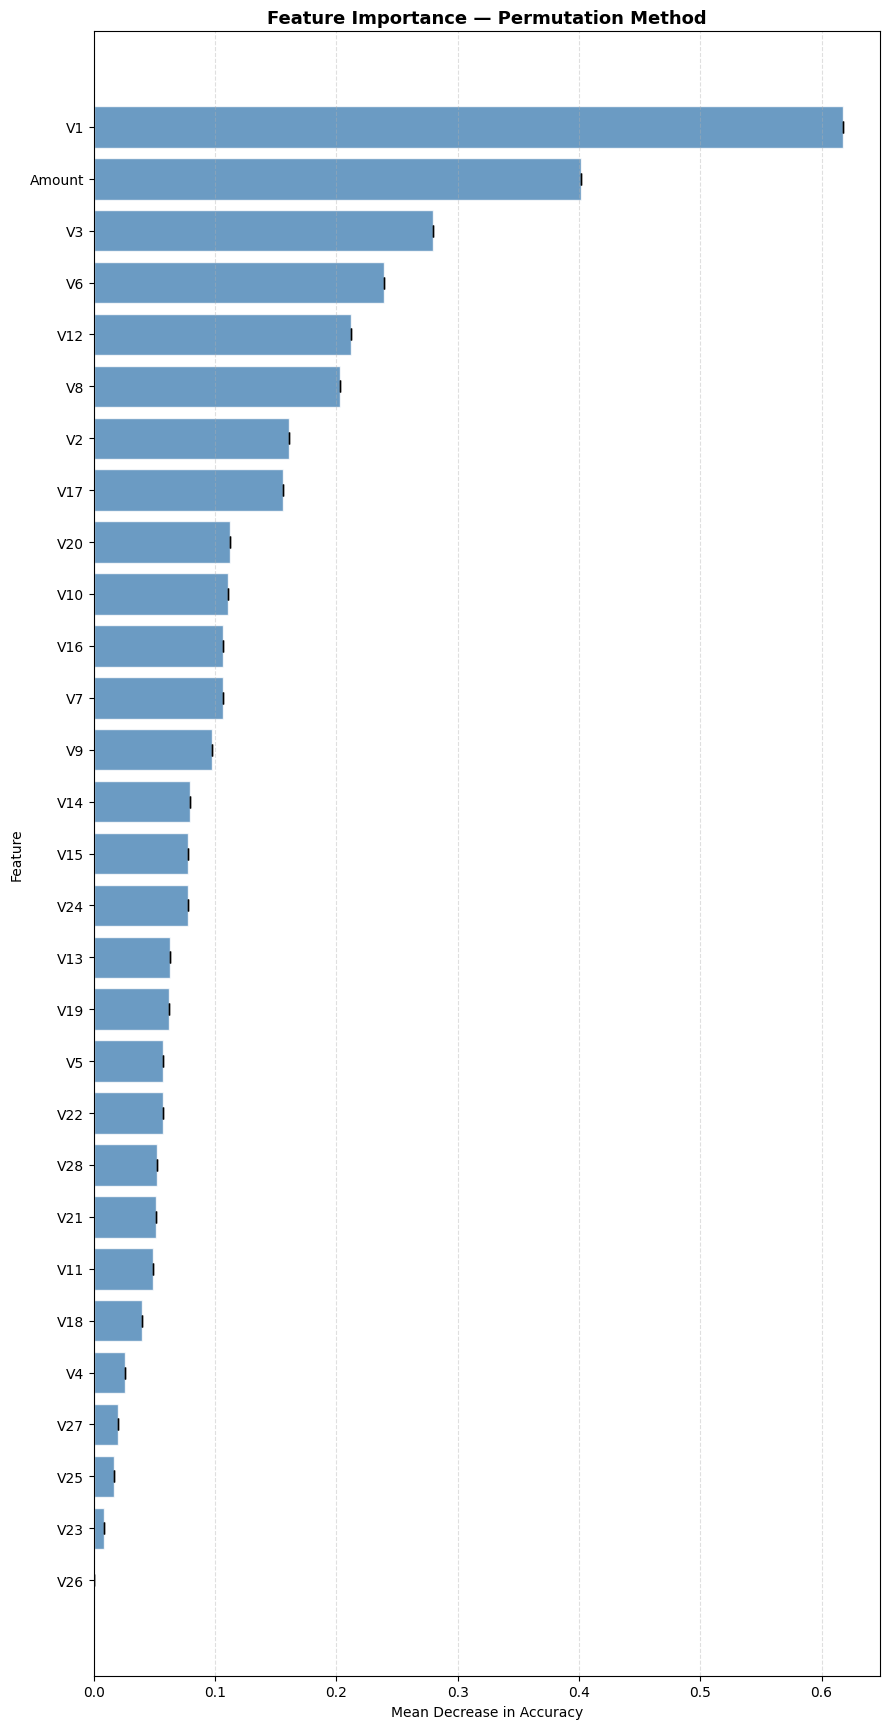

  ✔  Gambar disimpan: output/images/feature_importance.png

  Fitur Paling Berpengaruh : V1

✔  Feature importance selesai.


In [13]:
# ── 12. FEATURE IMPORTANCE (PERMUTATION) ────────────────────────────────────────
section("12. FEATURE IMPORTANCE APPROXIMATION")
cprint("  Menggunakan Korelasi Absolut dengan Anomaly Score...", C.WHITE)

# Buat pseudo-labels: 1 = normal, 0 = anomaly  (untuk scoring)
# y_pseudo = (y_pred == 1).astype(int)

# from sklearn.inspection import permutation_importance as perm_imp

# Feature importance berdasarkan korelasi absolut tiap fitur dengan anomaly score
# Semakin tinggi korelasi → fitur makin berpengaruh terhadap skor anomali
importance_vals = [
    abs(np.corrcoef(df_num[col].values, scores)[0, 1]) for col in num_cols
]

feat_imp_df = (
    pd.DataFrame(
        {
            "Feature": num_cols,
            "Importance": importance_vals,
            "Std Dev": [0.0] * len(num_cols),  # tidak ada std di metode ini
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)


feat_imp_df.index += 1
cprint("  Ranking Fitur (Permutation Importance):", C.YELLOW, bold=True)
display(feat_imp_df.style.background_gradient(subset=["Importance"], cmap="Blues"))

# Bar Chart
fig, ax = plt.subplots(figsize=(9, max(4, len(num_cols) * 0.6)))
bars = ax.barh(
    feat_imp_df["Feature"][::-1],
    feat_imp_df["Importance"][::-1],
    xerr=feat_imp_df["Std Dev"][::-1],
    color="steelblue",
    alpha=0.8,
    edgecolor="white",
    capsize=4,
)
ax.set_title("Feature Importance — Permutation Method", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean Decrease in Accuracy")
ax.set_ylabel("Feature")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
save_fig(fig, "feature_importance.png")

top_feature = feat_imp_df.iloc[0]["Feature"]
cprint(f"\n  Fitur Paling Berpengaruh : {C.YELLOW}{top_feature}{C.RESET}", C.WHITE)
cprint("\n✔  Feature importance selesai.", C.GREEN, bold=True)

In [14]:
# ── 13. SIMPAN HASIL ───────────────────────────────────────────────────────────
section("13. SIMPAN HASIL")

save_cols = list(num_cols) + ["anomaly_score", "anomaly", "label"]
output_csv = DIR_REPORTS / "anomaly_result.csv"

df_result[save_cols].to_csv(output_csv, index=False)

cprint(f"  ✔  Hasil deteksi disimpan ke : {C.GREEN}{output_csv}{C.RESET}", C.WHITE)
cprint(f"     Total baris : {len(df_result):,}", C.WHITE)
cprint(f"     Total kolom : {len(save_cols)}", C.WHITE)

print()
cprint("  Preview output CSV (5 baris pertama):", C.YELLOW, bold=True)
display(pd.read_csv(output_csv).head())

cprint("\n✔  File CSV berhasil disimpan.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  13. SIMPAN HASIL
════════════════════════════════════════════════════════════
  ✔  Hasil deteksi disimpan ke : output/reports/anomaly_result.csv
     Total baris : 283,726
     Total kolom : 32

  Preview output CSV (5 baris pertama):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,anomaly_score,anomaly,label
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.275693,1,Normal
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.303427,1,Normal
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.204438,1,Normal
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.256491,1,Normal
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.278091,1,Normal



✔  File CSV berhasil disimpan.


In [15]:
# ── 14. SIMPAN MODEL ───────────────────────────────────────────────────────────
section("14. SIMPAN MODEL")

model_path = DIR_MODEL / "isolation_forest.pkl"
scaler_path = DIR_MODEL / "standard_scaler.pkl"

joblib.dump(iso_forest, model_path)
joblib.dump(scaler, scaler_path)

model_size = model_path.stat().st_size / 1024
scaler_size = scaler_path.stat().st_size / 1024

cprint(
    f"  ✔  Model disimpan    : {C.GREEN}{model_path}{C.RESET}  ({model_size:.1f} KB)",
    C.WHITE,
)
cprint(
    f"  ✔  Scaler disimpan   : {C.GREEN}{scaler_path}{C.RESET}  ({scaler_size:.1f} KB)",
    C.WHITE,
)

print()
cprint("  Cara memuat model kembali:", C.YELLOW, bold=True)
cprint(
    C.WHITE,
)

cprint("\n✔  Model berhasil disimpan menggunakan joblib.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  14. SIMPAN MODEL
════════════════════════════════════════════════════════════
  ✔  Model disimpan    : output/model/isolation_forest.pkl  (1670.1 KB)
  ✔  Scaler disimpan   : output/model/standard_scaler.pkl  (1.7 KB)

  Cara memuat model kembali:


✔  Model berhasil disimpan menggunakan joblib.


In [16]:
# ── 15. KESIMPULAN OTOMATIS ───────────────────────────────────────────────────
section("15. KESIMPULAN OTOMATIS")

img_files = sorted(DIR_IMAGES.glob("*.png"))
top_features = feat_imp_df["Feature"].head(3).tolist()

bar = "─" * 58
print(f"{C.BOLD}{C.PURPLE}")
print(f"  ┌{bar}┐")
print(f"  │{'RINGKASAN HASIL ANOMALY DETECTION':^58}│")
print(f"  ├{bar}┤")
print(f"  │  {'Total Data':30}: {len(df_result):>10,}           │")
print(f"  │  {'Jumlah Fitur':30}: {len(num_cols):>10}           │")
print(f"  │  {'Jumlah Normal':30}: {total_normal:>10,}           │")
print(f"  │  {'Jumlah Anomali':30}: {total_anomaly:>10,}           │")
print(f"  │  {'Persentase Anomali':30}: {pct_anomaly:>9.2f}%           │")
print(f"  │  {'Avg Anomaly Score':30}: {scores.mean():>10.6f}           │")
print(f"  ├{bar}┤")
print(f"  │  {'Top 3 Fitur Berpengaruh':}                              │")
for i, feat in enumerate(top_features, 1):
    print(f"  │    {i}. {feat:<52}│")
print(f"  ├{bar}┤")
print(f"  │  {'Output Files':}                                        │")
print(f"  │    CSV    : output/reports/anomaly_result.csv          │")
print(f"  │    Model  : output/model/isolation_forest.pkl          │")
print(f"  │    Scaler : output/model/standard_scaler.pkl           │")
print(f"  │    Gambar : output/images/ ({len(img_files)} files)               │")
print(f"  └{bar}┘")
print(f"{C.RESET}")

cprint("✔  Notebook selesai dijalankan. Semua output tersimpan.", C.GREEN, bold=True)


════════════════════════════════════════════════════════════
  15. KESIMPULAN OTOMATIS
════════════════════════════════════════════════════════════

  ┌──────────────────────────────────────────────────────────┐
  │            RINGKASAN HASIL ANOMALY DETECTION             │
  ├──────────────────────────────────────────────────────────┤
  │  Total Data                    :    283,726           │
  │  Jumlah Fitur                  :         29           │
  │  Jumlah Normal                 :    283,253           │
  │  Jumlah Anomali                :        473           │
  │  Persentase Anomali            :      0.17%           │
  │  Avg Anomaly Score             :   0.252235           │
  ├──────────────────────────────────────────────────────────┤
  │  Top 3 Fitur Berpengaruh                              │
  │    1. V1                                                  │
  │    2. Amount                                              │
  │    3. V3                                      